# **Diabetes Classification using XGBoost**

Welcome to this interactive data science tutorial! In this notebook, we will build a complete machine learning pipeline from scratch to predict diabetes using the BRFSS 2015 dataset.

### **Learning Objectives:**
1. Understand how to load compressed data formats (`.parquet`).
2. Perform feature selection and target isolation.
3. Partition data into training and testing splits to avoid data leakage.
4. Handle severe class imbalances using mathematical weighting techniques.
5. Train, evaluate, and save an extreme gradient boosting (**XGBoost**) classifier.

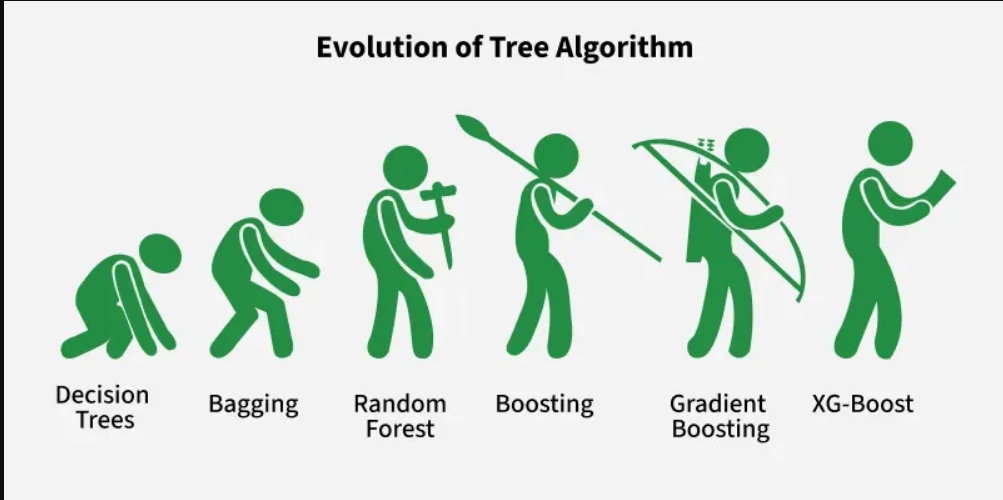

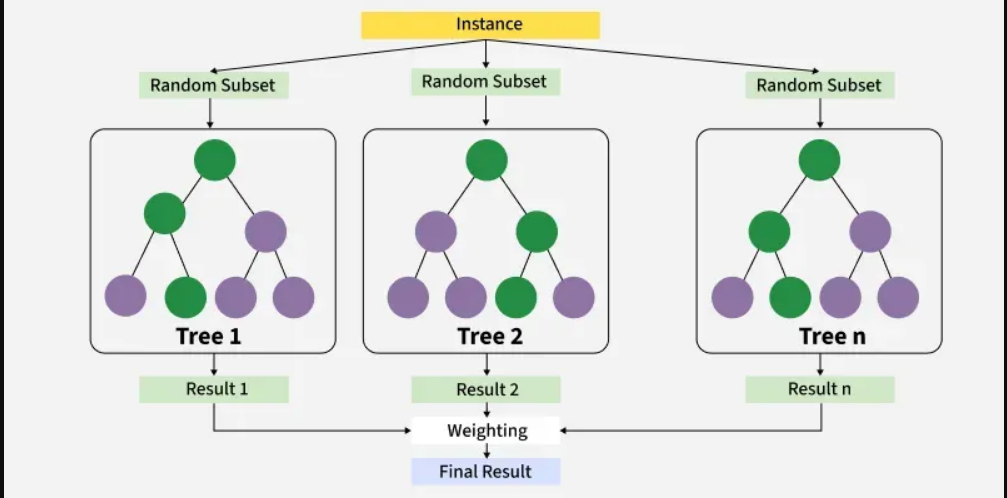

---
## **Step 1: Code Dependencies & Module Imports**

Before writing any core logic, we must load our tooling environment. We use built-in Python libraries for file operations and specialized third-party libraries for data modeling and evaluation.

In [1]:
# 'os' allows us to safely interact with the operating system filesystem across Windows/Mac/Linux
import os

# 'pickle' serializes Python objects into a byte stream so we can save models to a hard drive
import pickle

# 'pandas' creates powerful data structures (DataFrames) for tabular data manipulation
import pandas as pd

# 'train_test_split' shuffles and partitions data cleanly into training and evaluation blocks
from sklearn.model_selection import train_test_split

# 'accuracy_score' computes the ratio of correct predictions to total test items
from sklearn.metrics import accuracy_score

# 'xgboost' provides the high-performance gradient boosted decision tree library
import xgboost as xgb

print("Step 1: All libraries imported successfully!")

Step 1: All libraries imported successfully!


---
## **Step 2: Environment Configuration & Directory Paths**

In standard Python scripts, the absolute path of the script is tracked via `__file__`. However, in interactive environments like Jupyter Notebooks, we utilize `os.getcwd()` (Get Current Working Directory) to build solid relative pathways.

In [6]:
BASE_DIR = os.getcwd()
print(f"Step 2: Current working directory is '{BASE_DIR}'")

DATASET_PATH = os.path.join(BASE_DIR, "data", "processed", "diabetes.parquet")
print(f"Step 3: Dataset path set to '{DATASET_PATH}'")

Step 2: Current working directory is 'd:\AI Projects\Full AI-Healthcare-System\AI-Healthcare-System'
Step 3: Dataset path set to 'd:\AI Projects\Full AI-Healthcare-System\AI-Healthcare-System\data\processed\diabetes.parquet'


In [7]:
# Identify the current active folder containing this notebook
BASE_DIR = os.getcwd()

# Build the explicit path pointing to where our structured data is stored
DATASET_PATH = os.path.join(BASE_DIR, "data", "processed", "diabetes.parquet")

# Define the target file name where our finalized model will be exported
MODEL_PATH = os.path.join(BASE_DIR, "diabetes_model.pkl")

print(f"Dataset location path configured at: {DATASET_PATH}")
print(f"Model export path configured at: {MODEL_PATH}")

Dataset location path configured at: d:\AI Projects\Full AI-Healthcare-System\AI-Healthcare-System\data\processed\diabetes.parquet
Model export path configured at: d:\AI Projects\Full AI-Healthcare-System\AI-Healthcare-System\diabetes_model.pkl


---
## **Step 3: Dataset Ingestion (Loading)**

We read our data using a format called **Parquet**. Parquet is a columnar storage file format optimized for fast, memory-efficient data retrieval compared to heavy plain-text CSV files.

In [8]:
# Defensive coding check: ensure the file exists before attempting to read it
if not os.path.exists(DATASET_PATH):
    print(f"[Error]: Dataset not found at {DATASET_PATH}. Please verify the file path location!")
else:
    # Ingest the compressed Parquet data straight into a structured pandas DataFrame
    df = pd.read_parquet(DATASET_PATH)
    
    # Log validation metrics summarizing data extraction scale
    print(f"Successfully Loaded Dataset! Total entries parsed: {len(df)} rows")

Successfully Loaded Dataset! Total entries parsed: 253680 rows


---
## **Step 4: Data Preprocessing, Mapping, & Variable Isolation**

To make our tabular data digestible for the model, we isolate our prediction parameters (**Features**) from what we want to predict (**Target**).

> *Note: This cell assumes a secondary module named `features.py` resides in the same directory to provide standard column structures.*

In [9]:
# Safeguard against file import configurations using structured try/except syntax
try:
    from backend.features import DIABETES_DATASET_MAP, DIABETES_FEATURES
except ImportError:
    from backend.features import DIABETES_DATASET_MAP, DIABETES_FEATURES

# Normalize original column names into clean, readable system metrics
if all(col in df.columns for col in DIABETES_DATASET_MAP.keys()):
    print("Renaming columns to canonical names...")
    df = df.rename(columns=DIABETES_DATASET_MAP)

# Isolate Features (X): Descriptive independent variables used to inform the model
X = df[DIABETES_FEATURES]

# Isolate Target (Y): The dependent outcome variable containing diabetes metrics
Y = df["diabetes"]

print(f"Pipeline operational. Active modeling features: {X.columns.tolist()}")

Renaming columns to canonical names...
Pipeline operational. Active modeling features: ['hypertension', 'high_chol', 'bmi', 'smoking_history', 'heart_disease', 'physical_activity', 'general_health', 'gender', 'age_bucket']


---
## **Step 5: Data Splitting (Train/Test Partitioning)**

Evaluating models on data they already looked at creates biased performance estimations (**overfitting**). We separate our information chunks: 80% to feed the mathematical model during optimization, and 20% isolated purely for final evaluation.

In [10]:
# Partition data arrays systematically.
# 'test_size=0.2' guarantees a clean 80/20 data breakdown.
# 'random_state=42' freezes the data randomizer matrix so you see exact matching results every run.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set scope finalized: {X_train.shape[0]} samples assigned")
print(f"Testing evaluation scope finalized: {X_test.shape[0]} samples isolated")

Training set scope finalized: 202944 samples assigned
Testing evaluation scope finalized: 50736 samples isolated


---
## **Step 6: Class Imbalance Stabilization & Model Training**

Medical classification data typically contains highly skewed ratios (significantly more healthy patients than diagnosed patients). Unchecked algorithms quickly learn to guess 'healthy' universally to hit artificially high performance numbers.

We calculate an imbalance adjustment weight via the equation:
$$scale\_pos\_weight = \frac{\text{Total Negative Sample Space}}{\text{Total Positive Sample Space}}$$

In [11]:
# Sum historical records indicating negative case scenarios (0)

neg_count = int((Y_train == 0).sum())

# Sum historical records demonstrating positive conditions (1 and 2 representing pre/post conditions)
pos_count = int((Y_train == 1).sum()) + int((Y_train == 2).sum())

# Generate penalization ratio for minor scale groups. Falls back to 1.0 to prevent zero division errors
scale_weight = neg_count / pos_count if pos_count > 0 else 1.0

print(f"Training distribution profile: Negatives={neg_count}, Positives={pos_count}")
print(f"Calculated optimization penalty weight (scale_pos_weight): {scale_weight:.2f}")

# Initialize the extreme gradient boosted tree classifier using default hyperparameters
model = xgb.XGBClassifier(
    n_estimators=200,          # Construct up to 200 progressive sequential trees
    max_depth=6,               # Establish standard tree depth constraints to curb overfitting bounds
    learning_rate=0.1,         # Implement step scaling shrinkage to optimize training paths carefully
    scale_pos_weight=scale_weight, # Apply class weight balance penalty parameters computed above
    eval_metric='logloss',     # Monitor validation loss during network matrix operations
    random_state=42            # Explicitly enforce stable initialization parameters
)

print("\nInitializing XGBoost structural fit procedures...")
# Train the classifier structure to map dependencies securely
model.fit(X_train, Y_train)
print("Model optimization sequence complete!")

Training distribution profile: Negatives=174595, Positives=28349
Calculated optimization penalty weight (scale_pos_weight): 6.16

Initializing XGBoost structural fit procedures...
Model optimization sequence complete!


---
## **Step 7: Prediction Performance Metrics & Local Export**

Now we validate our optimized modeling weights using the isolated testing sets. Then we output the finished python structure directly onto local storage utilizing `pickle` mechanics for future deployment operations.

In [12]:
# Generate binary array projections over testing feature datasets
y_pred = model.predict(X_test)

# Score validation projections against actual observed values
acc = accuracy_score(Y_test, y_pred)
print(f"Pipeline Performance Assessment -> Model Accuracy: {acc:.4f} ({acc * 100:.2f}%)")

# Instantiate storage pipeline via secure system file-write binaries ('wb') mode
# with open(MODEL_PATH, 'wb') as f:
#     # Export internal model parameter arrays natively via serialization mechanics
#     pickle.dump(model, f)

print(f"Success! Trained XGBoost serialization pipeline exported to: {MODEL_PATH}")

Pipeline Performance Assessment -> Model Accuracy: 0.7166 (71.66%)
Success! Trained XGBoost serialization pipeline exported to: d:\AI Projects\Full AI-Healthcare-System\AI-Healthcare-System\diabetes_model.pkl
